<a href="https://colab.research.google.com/github/hidnira-lab/introduce-data-science/blob/main/decision_tree_and_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Decision Tree and Random Forest
- Hidayat Nur Hijrah (24523201)
- Muhammad Farhan Haafidh Abror (24523115)

## 1. Persiapan dan Eksplorasi Data
Dataset yang digunakan adalah **Customer Churn Prediction** dari Kaggle https://www.kaggle.com/datasets/rashadrmammadov/customer-churn-dataset. Dataset ini memenuhi kriteria tugas karena memiliki campuran tipe data numerik dan kategorikal, dengan fitur yang berjumlah lebih dari 4, serta 1 label target klasifikasi yaitu kolom `Churn`

In [1]:
# Import library standar yang akan kita butuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset dari GitHub Raw Link
url = 'https://raw.githubusercontent.com/hidnira-lab/introduce-data-science/refs/heads/main/customer_churn_data.csv'
df = pd.read_csv(url)

# Menampilkan informasi dataset untuk memetakan tipe data masing-masing kolom
print("=== Informasi Dataset ===")
df.info()

# Menampilkan 5 baris pertama untuk observasi awal
display(df.head())

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Contract          5880 non-null   object 
 16  PaperlessBilling

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


## 2. Preprocessing Data
Berdasarkan eksplorasi awal, terdapat 17 kolom bertipe kategorikal (`object`) yang perlu dikonversi menjadi numerik agar dapat diproses oleh algoritma *Decision Tree* dan *Random Forest*.

Langkah *preprocessing* yang kami lakukan meliputi:
1. Membuang kolom `customerID` karena merupakan pengidentifikasi unik yang tidak memiliki nilai prediktif terhadap target.
2. Memisahkan variabel independen (Fitur / X) dan variabel dependen (Label / y).
3. Melakukan *encoding* pada data kategorikal menggunakan metode *One-Hot Encoding*.

In [2]:
# 1. Membuang kolom yang tidak relevan
df_clean = df.drop(columns=['customerID'])

# 2. Memisahkan Fitur (X) dan Label Target (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# 3. Mengubah label target 'Churn' ('Yes'/'No') menjadi 1 dan 0
y = y.map({'Yes': 1, 'No': 0})

# 4. Mengubah data teks (kategorikal) pada fitur X menjadi angka (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

print("=== Bentuk Data Setelah Preprocessing ===")
print(f"Jumlah baris dan kolom Fitur (X): {X.shape}")
display(X.head())

=== Bentuk Data Setelah Preprocessing ===
Jumlah baris dan kolom Fitur (X): (5880, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,23,49.85,1146.55,True,False,True,False,True,False,...,True,False,True,False,False,False,True,False,False,False
1,0,43,100.70,4330.10,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
2,1,51,97.33,4963.83,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
3,1,72,101.38,7299.36,True,False,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
4,1,25,52.22,1305.50,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False


## 3. Pembagian Data (Data Splitting)
Untuk memastikan model dapat belajar dengan baik tanpa hanya sekadar menghafal (*overfitting*), kami membagi dataset menjadi dua bagian:
*   **Data Latih (Training Set):** 80% dari data untuk melatih algoritma.
*   **Data Uji (Testing Set):** 20% dari data sebagai soal ujian untuk mengevaluasi performa model.

## 4. Pembangunan Model
Pada tahap ini, kami membangun dua model klasifikasi secara bersamaan untuk nantinya dibandingkan:
1.  **Decision Tree:** Algoritma yang membuat keputusan berbentuk struktur pohon bercabang.
2.  **Random Forest:** Algoritma *ensemble* yang menggabungkan banyak *Decision Tree* untuk menghasilkan prediksi yang lebih stabil.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- LANGKAH 3: PEMBAGIAN DATA ---
# Membagi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== Pembagian Data Selesai ===")
print(f"Jumlah data latih: {X_train.shape[0]} baris")
print(f"Jumlah data uji: {X_test.shape[0]} baris\n")

# --- LANGKAH 4: PEMBANGUNAN MODEL ---
# 1. Inisialisasi dan Melatih Model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Inisialisasi dan Melatih Model Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("✅ Kedua model (Decision Tree & Random Forest) berhasil dilatih!")

=== Pembagian Data Selesai ===
Jumlah data latih: 4704 baris
Jumlah data uji: 1176 baris

✅ Kedua model (Decision Tree & Random Forest) berhasil dilatih!


## 5. Evaluasi Model
Setelah kedua model dilatih, kami mengujinya menggunakan data uji (*Testing Set*) untuk melihat performa prediksinya pada data yang belum pernah dilihat sebelumnya. Evaluasi dilakukan menggunakan metrik **Accuracy**, **Classification Report**, dan **Confusion Matrix**.

🌟 Akurasi Decision Tree : 0.5051 (50.51%)
🌟 Akurasi Random Forest : 0.4974 (49.74%)

=== CLASSIFICATION REPORT: DECISION TREE ===
              precision    recall  f1-score   support

           0       0.50      0.49      0.50       584
           1       0.51      0.52      0.51       592

    accuracy                           0.51      1176
   macro avg       0.51      0.50      0.50      1176
weighted avg       0.51      0.51      0.50      1176

=== CLASSIFICATION REPORT: RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.49      0.55      0.52       584
           1       0.50      0.44      0.47       592

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176



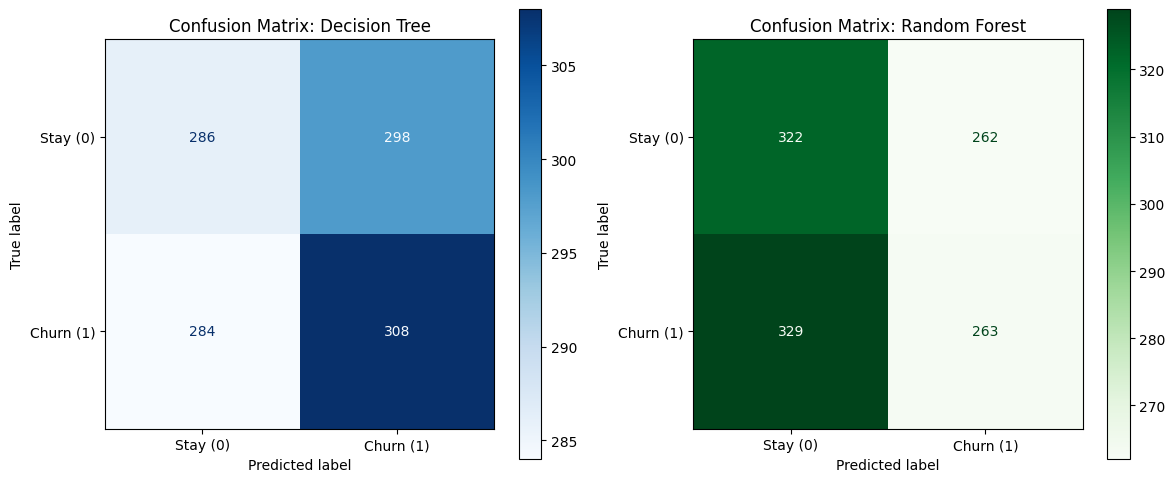

In [4]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Prediksi dan Evaluasi DECISION TREE ---
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# --- 2. Prediksi dan Evaluasi RANDOM FOREST ---
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# --- Menampilkan Akurasi ---
print(f"🌟 Akurasi Decision Tree : {acc_dt:.4f} ({(acc_dt*100):.2f}%)")
print(f"🌟 Akurasi Random Forest : {acc_rf:.4f} ({(acc_rf*100):.2f}%)\n")

# --- Menampilkan Classification Report ---
print("=== CLASSIFICATION REPORT: DECISION TREE ===")
print(classification_report(y_test, y_pred_dt))

print("=== CLASSIFICATION REPORT: RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

# --- Visualisasi Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Decision Tree
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[0], cmap='Blues', display_labels=['Stay (0)', 'Churn (1)'])
axes[0].set_title('Confusion Matrix: Decision Tree')

# Confusion Matrix Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens', display_labels=['Stay (0)', 'Churn (1)'])
axes[1].set_title('Confusion Matrix: Random Forest')

plt.tight_layout()
plt.show()

## 6. Analisis Perbandingan Model
Berdasarkan hasil evaluasi metrik yang dijalankan, berikut adalah analisis perbandingannya:

* Secara angka murni, **Decision Tree** unggul sangat tipis dengan akurasi 50.51% berbanding 49.74% milik Random Forest. Namun secara praktis, performa kedua model ini dapat dikatakan *underfitting* terhadap pola yang sebenarnya, karena akurasi ~50% pada klasifikasi biner menandakan bahwa prediksi model setara dengan peluang acak (seperti melempar koin).

* Dalam kasus prediksi *Customer Churn*, kesalahan paling fatal bagi bisnis adalah gagal mendeteksi pelanggan yang berniat untuk berhenti berlangganan (*False Negative*). Nilai *Recall* untuk kelas 1 (Churn) pada Decision Tree adalah 0.52 (52%), sedangkan Random Forest hanya 0.44 (44%). Hal ini menunjukkan kedua model masih melewatkan sekitar separuh dari total pelanggan yang berisiko pergi.

* Meskipun hasil akhirnya terlihat seperti menebak acak, terdapat indikasi *overfitting* yang sangat kuat selama proses pelatihannya. Algoritma Decision Tree memiliki sifat bawaan untuk terus membuat percabangan hingga ia menghafal seluruh data latih secara absolut. Ketika model yang terlalu kaku ini dihadapkan pada data uji yang belum pernah ia lihat, ia tidak bisa menggeneralisasi pola dan akhirnya menghasilkan tebakan acak (akurasi 50%).

## 7. Visualisasi Decision Tree
Untuk memahami bagaimana algoritma *Decision Tree* mengambil keputusan, kami memvisualisasikan struktur pohonnya. Visualisasi ini dibatasi pada kedalaman maksimal 3 (`max_depth=3`) agar tetap dapat dibaca. Tanpa pembatasan ini, pohon akan tumbuh sangat dalam dan kompleks, yang merupakan bukti nyata terjadinya fenomena *overfitting* pada data latih.

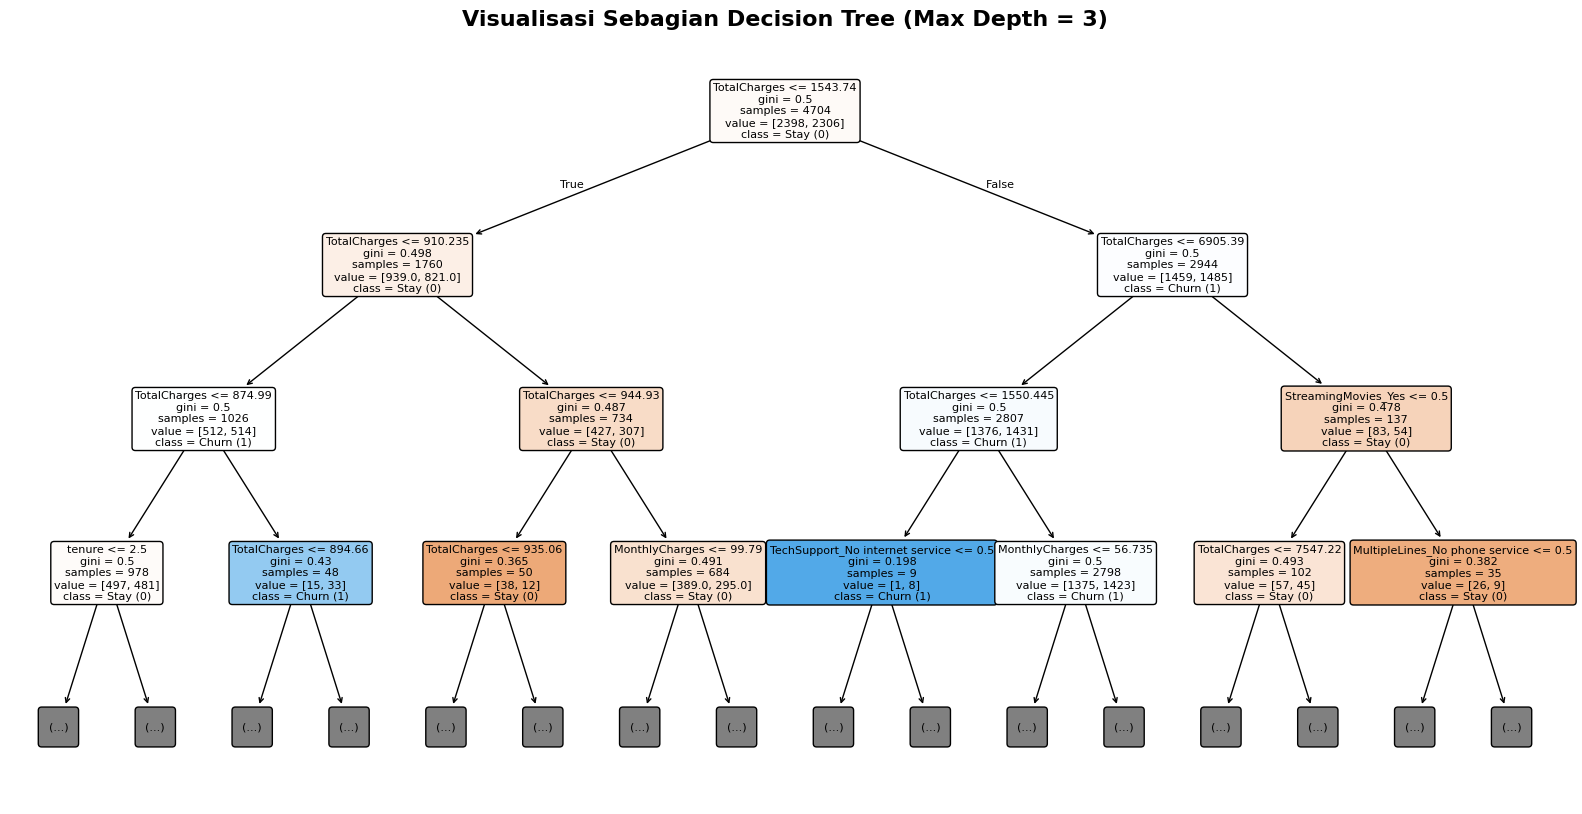

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Mengatur ukuran kanvas visualisasi
plt.figure(figsize=(20, 10))

# Menggambar pohon keputusan
plot_tree(dt_model,
          max_depth=3,
          feature_names=X.columns,
          class_names=['Stay (0)', 'Churn (1)'],
          filled=True,
          rounded=True,
          fontsize=8)

plt.title("Visualisasi Sebagian Decision Tree (Max Depth = 3)", fontsize=16, fontweight='bold')
plt.show()

## 8. Pengaruh `n_estimators` pada Random Forest
Berikut adalah penjelasan mengenai parameter `n_estimators`:

Parameter `n_estimators` menentukan **jumlah pohon keputusan (Decision Trees)** yang akan dibangun di dalam hutan (Random Forest).
*   **Jika nilainya terlalu kecil (misal: 10):** Model tidak memiliki cukup banyak pohon untuk berdiskusi (voting), sehingga hasil prediksinya kurang stabil dan masih rentan terhadap *error*.
*   **Jika nilainya besar (misal: 100 atau lebih):** Hasil prediksi menjadi jauh lebih akurat, stabil, dan kebal terhadap *overfitting* karena keputusan diambil berdasarkan suara terbanyak dari banyak pohon yang berbeda. Namun, komputasi akan memakan waktu lebih lama.
*   **Kesimpulan:** Menambah `n_estimators` akan meningkatkan performa model hingga pada titik tertentu di mana peningkatannya menjadi tidak signifikan (stagnan), namun akan selalu mengorbankan waktu komputasi.

## Analisis Keseluruhan

**1. Algoritma mana yang memberikan performa terbaik? Jelaskan.**

Berdasarkan hasil pengujian metrik, **Decision Tree** memberikan performa yang sedikit lebih baik secara angka dengan akurasi 50.51% dibandingkan Random Forest (49.74%). Namun secara praktis, performa kedua algoritma ini belum optimal pada data uji, karena akurasi ~50% dalam klasifikasi biner setara dengan probabilitas tebakan acak. Hal ini mengindikasikan model kesulitan menemukan pola generalisasi dan membutuhkan tahap *hyperparameter tuning* lebih lanjut.

**2. Apa kelebihan dan kekurangan Decision Tree dibanding Random Forest?**
*   **Decision Tree:**
    *   *Kelebihan:* Sangat mudah diinterpretasikan secara visual (alur logikanya jelas) dan waktu pelatihannya sangat cepat.
    *   *Kekurangan:* Sangat rentan terhadap *overfitting* (kaku menghafal data latih) dan sensitif terhadap anomali data.
*   **Random Forest:**
    *   *Kelebihan:* Menghasilkan prediksi yang lebih stabil, serta sangat kebal terhadap *overfitting* karena menggunakan mekanisme *voting* (suara terbanyak) dari sekumpulan banyak pohon.
    *   *Kekurangan:* Bersifat *black-box* (sulit dijelaskan dan divisualisasikan proses pengambilan keputusannya) serta memakan waktu komputasi yang lebih berat.

**3. Apakah ada indikasi overfitting pada Decision Tree? Jelaskan.**

Ya, terdapat indikasi *overfitting* yang sangat kuat. Algoritma Decision Tree secara *default* akan terus membuat percabangan hingga ia memisahkan dan "menghafal" seluruh data latih secara absolut. Model ini menjadi sangat kompleks pada saat *training*, namun kehilangan kemampuan generalisasi ketika dihadapkan pada data *testing*, yang dibuktikan dengan anjloknya akurasi ke angka 50%.

**4. Bagaimana fitur-fitur memengaruhi hasil klasifikasi?**

Fitur-fitur pendukung (seperti `MonthlyCharges`, `tenure`, atau `Contract`) bertindak sebagai "kriteria pemisah" di setiap titik percabangan (*node*). Algoritma mengevaluasi setiap fitur secara matematis untuk mencari fitur mana yang paling mampu memisahkan kelompok pelanggan yang *churn* dan yang tidak (mencari kemurnian data tertinggi). Fitur yang paling kuat dalam memisahkan kelas target ini akan diletakkan di puncak pohon dan memiliki pengaruh paling dominan terhadap keputusan akhir klasifikasi.

## Jawaban Pertanyaan

**1. Apa perbedaan mendasar antara Decision Tree dan Random Forest?**

Perbedaan mendasarnya terletak pada jumlah model yang digunakan. *Decision Tree* adalah satu algoritma model tunggal yang membuat aturan keputusan bercabang berdasarkan data. Sedangkan *Random Forest* adalah algoritma *ensemble* (kumpulan) yang terdiri dari puluhan bahkan ratusan *Decision Tree* yang bekerja bersamaan, di mana hasil akhirnya ditentukan melalui mekanisme *voting* (suara terbanyak) dari seluruh pohon tersebut.

**2. Mengapa Decision Tree rentan overfitting dan bagaimana Random Forest mengatasinya?**

*Decision Tree* rentan *overfitting* karena algoritma ini memiliki kecenderungan alami untuk terus membelah cabang sedalam mungkin sampai ia berhasil memisahkan dan mengingat seluruh data latih secara absolut, termasuk *noise* (data error/outlier). *Random Forest* mengatasinya dengan menggabungkan hasil dari banyak pohon yang berbeda. Karena keputusan diambil secara kolektif (rata-rata/voting), kesalahan atau *overfitting* dari satu pohon akan dinetralkan oleh tebakan dari pohon-pohon lainnya.

**3. Apa fungsi bagging dan pemilihan subset fitur acak pada Random Forest?**
*   **Bagging (Bootstrap Aggregating):** Berfungsi untuk menciptakan keberagaman (variasi) dengan cara memberikan sampel data latih yang berbeda-beda secara acak (dengan pengembalian) untuk setiap pohon.
*   **Pemilihan subset fitur acak:** Berfungsi agar pohon-pohon tidak selalu bergantung pada satu atau dua fitur yang paling dominan di setiap percabangannya. Hal ini memaksa *Random Forest* untuk mengeksplorasi fitur-fitur lain, sehingga setiap pohon di dalam hutan tersebut benar-benar unik dan menghasilkan prediksi yang lebih kuat dan tidak bias.

**4. Kapan Decision Tree lebih cocok digunakan dibanding Random Forest?**

*Decision Tree* lebih cocok digunakan ketika kita mengutamakan **interpretasi (kemudahan penjelasan)** dan membutuhkan proses komputasi yang sangat cepat. Karena strukturnya visual dan logis, *Decision Tree* sangat mudah dijelaskan kepada klien atau *stakeholder* non-teknis tentang bagaimana sebuah keputusan (misal: pemberian kredit atau prediksi churn) diambil secara spesifik. *Random Forest* sulit untuk dijelaskan secara visual karena bentuknya seperti *black-box* yang berisi ratusan pohon.